# 02 — Parameter Sampling with Latin Hypercube Sampling

Goal: generate a reproducible parameter table for the 21 cm symbolic regression project.

Parameters:
- ζ: ionizing efficiency
- log10(Tvir / K): minimum virial temperature
- R_mfp: mean free path
- log10(L_X): X-ray heating efficiency proxy
- σ8: matter fluctuation amplitude

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "figures"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_RAW, FIGURES, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", DATA_RAW)
print("Figures directory:", FIGURES)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Raw data directory: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw
Figures directory: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures


In [3]:
RANDOM_SEED = 42
N_SAMPLES = 2000

print("Random seed:", RANDOM_SEED)
print("Number of LHS samples:", N_SAMPLES)

Random seed: 42
Number of LHS samples: 2000


In [4]:
parameter_ranges = {
    "zeta": {
        "symbol": r"$\zeta$",
        "description": "Ionizing efficiency",
        "min": 10.0,
        "max": 80.0,
        "unit": "dimensionless",
    },
    "log10_Tvir": {
        "symbol": r"$\log_{10}(T_{\mathrm{vir}}/\mathrm{K})$",
        "description": "Minimum virial temperature",
        "min": 4.0,
        "max": 5.5,
        "unit": "log10(K)",
    },
    "R_mfp": {
        "symbol": r"$R_{\mathrm{mfp}}$",
        "description": "Mean free path",
        "min": 5.0,
        "max": 30.0,
        "unit": "Mpc",
    },
    "log10_LX": {
        "symbol": r"$\log_{10}(L_X)$",
        "description": "X-ray luminosity / heating-efficiency proxy",
        "min": 38.0,
        "max": 42.0,
        "unit": "log10",
    },
    "sigma8": {
        "symbol": r"$\sigma_8$",
        "description": "Matter fluctuation amplitude",
        "min": 0.75,
        "max": 0.90,
        "unit": "dimensionless",
    },
}

parameter_names = list(parameter_ranges.keys())
n_dim = len(parameter_names)

print("Parameters:")
for name in parameter_names:
    info = parameter_ranges[name]
    print(f"{name}: [{info['min']}, {info['max']}]")

Parameters:
zeta: [10.0, 80.0]
log10_Tvir: [4.0, 5.5]
R_mfp: [5.0, 30.0]
log10_LX: [38.0, 42.0]
sigma8: [0.75, 0.9]


In [5]:
sampler = qmc.LatinHypercube(
    d=n_dim,
    seed=RANDOM_SEED
)

lhs_unit = sampler.random(n=N_SAMPLES)

print("Unit LHS shape:", lhs_unit.shape)
print("Minimum unit value:", lhs_unit.min())
print("Maximum unit value:", lhs_unit.max())

Unit LHS shape: (2000, 5)
Minimum unit value: 5.851813331707035e-07
Maximum unit value: 0.9998992402100306


In [6]:
lower_bounds = np.array([parameter_ranges[name]["min"] for name in parameter_names])
upper_bounds = np.array([parameter_ranges[name]["max"] for name in parameter_names])

lhs_physical = qmc.scale(lhs_unit, lower_bounds, upper_bounds)

print("Physical LHS shape:", lhs_physical.shape)
print("First row:", lhs_physical[0])

Physical LHS shape: (2000, 5)
First row: [39.16291154  5.21092084 11.56426753 41.59860526  0.75464294]


In [7]:
parameter_df = pd.DataFrame(lhs_physical, columns=parameter_names)

parameter_df.insert(0, "simulation_id", np.arange(N_SAMPLES))

parameter_df.head()

,simulation_id,zeta,log10_Tvir,R_mfp,log10_LX,sigma8
0,0,39.162912,5.210921,11.564268,41.598605,0.754643
1,1,19.800853,4.957929,11.252674,38.931744,0.774341
2,2,54.227022,4.459055,21.379452,38.988354,0.848892
3,3,29.172047,5.018834,11.486702,41.166345,0.765703
4,4,70.803467,4.838234,6.200366,39.212214,0.820742


In [8]:
parameter_df["HII_EFF_FACTOR"] = parameter_df["zeta"]
parameter_df["ION_Tvir_MIN"] = parameter_df["log10_Tvir"]
parameter_df["R_BUBBLE_MAX"] = parameter_df["R_mfp"]
parameter_df["L_X"] = parameter_df["log10_LX"]
parameter_df["SIGMA_8"] = parameter_df["sigma8"]

parameter_df.head()

,simulation_id,zeta,log10_Tvir,R_mfp,log10_LX,sigma8,HII_EFF_FACTOR,ION_Tvir_MIN,R_BUBBLE_MAX,L_X,SIGMA_8
0,0,39.162912,5.210921,11.564268,41.598605,0.754643,39.162912,5.210921,11.564268,41.598605,0.754643
1,1,19.800853,4.957929,11.252674,38.931744,0.774341,19.800853,4.957929,11.252674,38.931744,0.774341
2,2,54.227022,4.459055,21.379452,38.988354,0.848892,54.227022,4.459055,21.379452,38.988354,0.848892
3,3,29.172047,5.018834,11.486702,41.166345,0.765703,29.172047,5.018834,11.486702,41.166345,0.765703
4,4,70.803467,4.838234,6.200366,39.212214,0.820742,70.803467,4.838234,6.200366,39.212214,0.820742


In [9]:
for name in parameter_names:
    min_allowed = parameter_ranges[name]["min"]
    max_allowed = parameter_ranges[name]["max"]

    actual_min = parameter_df[name].min()
    actual_max = parameter_df[name].max()

    print(f"{name}")
    print(f"  allowed: [{min_allowed}, {max_allowed}]")
    print(f"  actual : [{actual_min:.6f}, {actual_max:.6f}]")

    assert actual_min >= min_allowed
    assert actual_max <= max_allowed

print("All parameter ranges validated successfully.")

zeta
  allowed: [10.0, 80.0]
  actual : [10.000041, 79.986248]
log10_Tvir
  allowed: [4.0, 5.5]
  actual : [4.000340, 5.499849]
R_mfp
  allowed: [5.0, 30.0]
  actual : [5.007459, 29.995988]
log10_LX
  allowed: [38.0, 42.0]
  actual : [38.001543, 41.999294]
sigma8
  allowed: [0.75, 0.9]
  actual : [0.750035, 0.899972]
All parameter ranges validated successfully.


In [10]:
summary_df = parameter_df[parameter_names].describe().T

summary_df

,count,mean,std,min,25%,50%,75%,max
zeta,2000.0,45.000241,20.212563,10.000041,27.512789,45.006866,62.479926,79.986248
log10_Tvir,2000.0,4.750000,0.433116,4.000340,4.374868,4.750238,5.124558,5.499849
R_mfp,2000.0,17.500006,7.218758,5.007459,11.250852,17.504661,23.749820,29.995988
log10_LX,2000.0,40.000005,1.154967,38.001543,39.001104,40.000677,40.998971,41.999294
sigma8,2000.0,0.825000,0.043312,0.750035,0.787540,0.825012,0.862478,0.899972


In [11]:
parameter_table_path = DATA_RAW / "lhs_parameter_table_n2000.csv"

parameter_df.to_csv(parameter_table_path, index=False)

print("Saved parameter table to:", parameter_table_path)

Saved parameter table to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/lhs_parameter_table_n2000.csv


In [12]:
lhs_metadata = {
    "notebook": "02_parameter_sampling_lhs.ipynb",
    "sampling_method": "LatinHypercube",
    "random_seed": RANDOM_SEED,
    "n_samples": N_SAMPLES,
    "n_parameters": n_dim,
    "parameter_names": parameter_names,
    "parameter_ranges": parameter_ranges,
    "notes": (
        "Initial small-scale parameter design for validating the "
        "21 cm symbolic-regression simulation pipeline. "
        "This is not yet the final production-scale dataset."
    ),
}

metadata_path = DATA_RAW / "lhs_metadata_n2000.json"

with open(metadata_path, "w") as f:
    json.dump(lhs_metadata, f, indent=2)

print("Saved metadata to:", metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/lhs_metadata_n2000.json


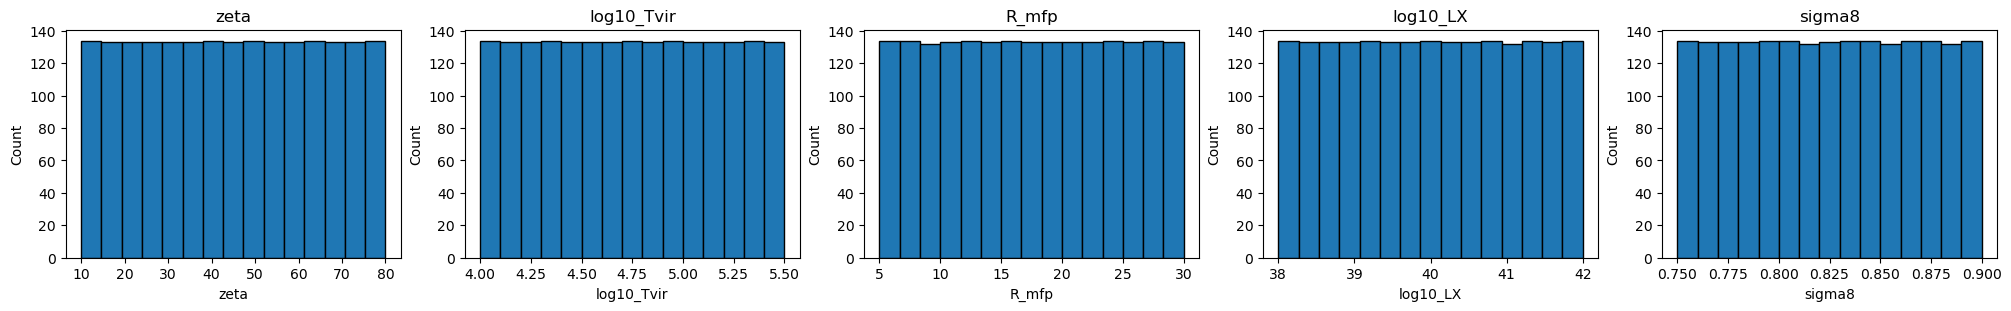

Saved histogram figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_histograms_n2000.png


In [13]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_dim,
    figsize=(4 * n_dim, 3),
    constrained_layout=True
)

for ax, name in zip(axes, parameter_names):
    ax.hist(parameter_df[name], bins=15, edgecolor="black")
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Count")

hist_path = FIGURES / "lhs_parameter_histograms_n2000.png"
plt.savefig(hist_path, dpi=300)
plt.show()

print("Saved histogram figure to:", hist_path)

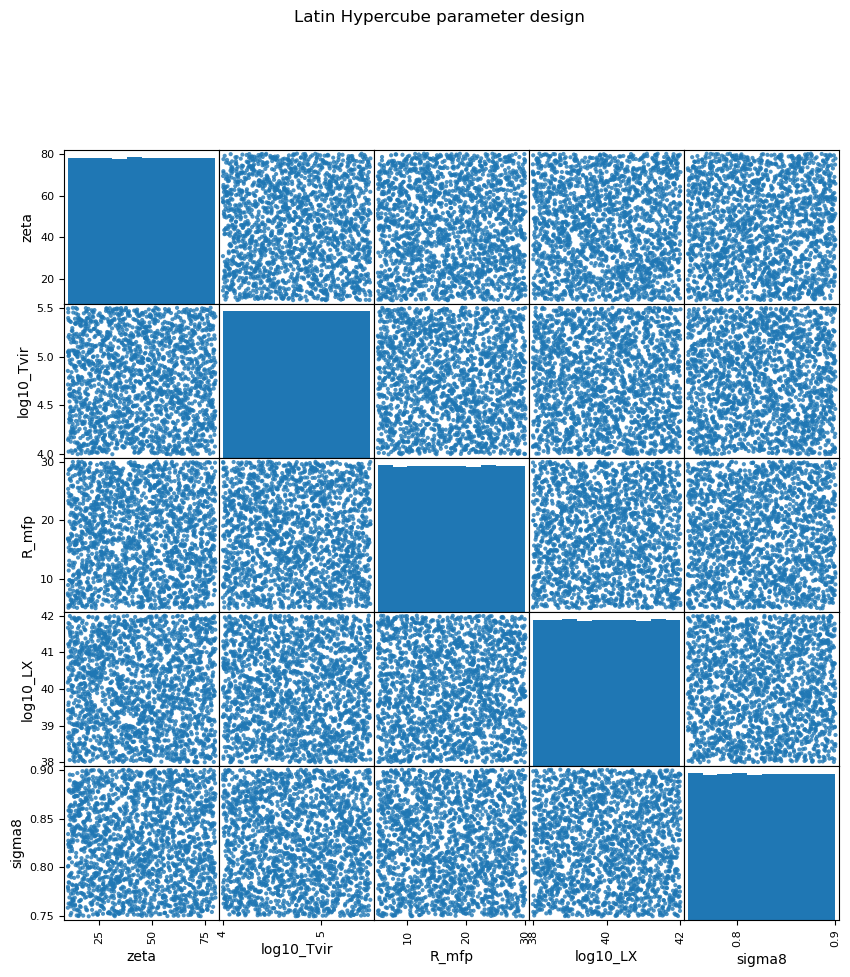

Saved scatter-matrix figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_scatter_matrix_n2000.png


In [14]:
pd.plotting.scatter_matrix(
    parameter_df[parameter_names],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.8
)

plt.suptitle("Latin Hypercube parameter design", y=1.02)

scatter_path = FIGURES / "lhs_parameter_scatter_matrix_n2000.png"
plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved scatter-matrix figure to:", scatter_path)

In [15]:
corr_df = parameter_df[parameter_names].corr()

corr_df

,zeta,log10_Tvir,R_mfp,log10_LX,sigma8
zeta,1.000000,-0.006348,-0.012924,-0.007041,0.006507
log10_Tvir,-0.006348,1.000000,-0.026048,-0.034946,-0.004350
R_mfp,-0.012924,-0.026048,1.000000,0.002535,0.004833
log10_LX,-0.007041,-0.034946,0.002535,1.000000,0.010603
sigma8,0.006507,-0.004350,0.004833,0.010603,1.000000


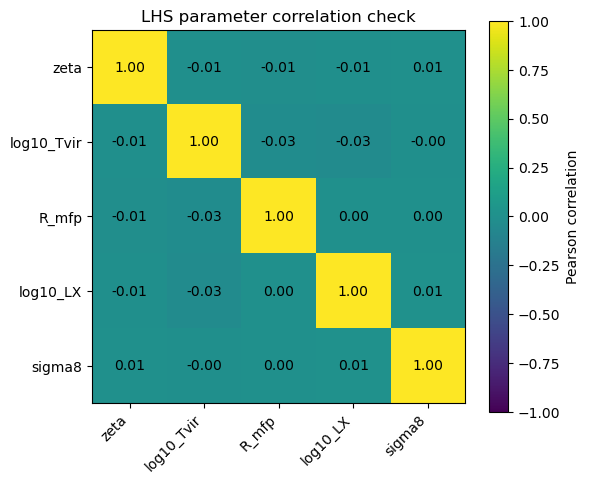

Saved correlation figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_correlation_matrix_n2000.png


In [16]:
plt.figure(figsize=(6, 5))

im = plt.imshow(corr_df.values, vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(n_dim),
    labels=parameter_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(n_dim),
    labels=parameter_names
)

plt.colorbar(im, label="Pearson correlation")

for i in range(n_dim):
    for j in range(n_dim):
        plt.text(
            j,
            i,
            f"{corr_df.values[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("LHS parameter correlation check")
plt.tight_layout()

corr_path = FIGURES / "lhs_parameter_correlation_matrix_n2000.png"
plt.savefig(corr_path, dpi=300)
plt.show()

print("Saved correlation figure to:", corr_path)

In [17]:
loaded_parameter_df = pd.read_csv(parameter_table_path)

with open(metadata_path, "r") as f:
    loaded_metadata = json.load(f)

print("Loaded parameter table shape:", loaded_parameter_df.shape)
print("Loaded metadata keys:", loaded_metadata.keys())

assert loaded_parameter_df.shape[0] == N_SAMPLES
assert loaded_metadata["n_samples"] == N_SAMPLES
assert loaded_metadata["random_seed"] == RANDOM_SEED

for name in parameter_names:
    assert name in loaded_parameter_df.columns

print("Saved parameter table and metadata validated successfully.")

Loaded parameter table shape: (2000, 11)
Loaded metadata keys: dict_keys(['notebook', 'sampling_method', 'random_seed', 'n_samples', 'n_parameters', 'parameter_names', 'parameter_ranges', 'notes'])
Saved parameter table and metadata validated successfully.


In [18]:
print("=" * 60)
print("Notebook 02 completed successfully.")
print("=" * 60)

print("Sampling method: Latin Hypercube Sampling")
print("Number of samples:", N_SAMPLES)
print("Number of parameters:", n_dim)

print("\nParameters:")
for name in parameter_names:
    info = parameter_ranges[name]
    print(f" - {name}: [{info['min']}, {info['max']}] {info['unit']}")

print("\nGenerated files:")
print(" -", parameter_table_path)
print(" -", metadata_path)
print(" -", hist_path)
print(" -", scatter_path)
print(" -", corr_path)

Notebook 02 completed successfully.
Sampling method: Latin Hypercube Sampling
Number of samples: 2000
Number of parameters: 5

Parameters:
 - zeta: [10.0, 80.0] dimensionless
 - log10_Tvir: [4.0, 5.5] log10(K)
 - R_mfp: [5.0, 30.0] Mpc
 - log10_LX: [38.0, 42.0] log10
 - sigma8: [0.75, 0.9] dimensionless

Generated files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/lhs_parameter_table_n2000.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/lhs_metadata_n2000.json
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_histograms_n2000.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_scatter_matrix_n2000.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/lhs_parameter_correlation_matrix_n2000.png
